In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import seaborn as sns

In [2]:
df2 = pd.read_csv("formulas.csv", index_col=0)
def get_solve_time(code_name):
    if code_name == "Steane":
        return float(df2.loc[r"bv_decide_queries"+"\\"+"steane_dist.cnf"]["solve_time"])
    elif code_name == "Golay":
        return float(df2.loc[r"bv_decide_queries"+"\\"+"golay_dist.cnf"]["solve_time"])
    return(float(df2.loc[r"bv_decide_queries"+"\\"+code_name+"_z_rank.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_x_rank.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_x_dist.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_z_dist.cnf"]["solve_time"]))

In [3]:
csv_file="build_times.csv"
df = pd.read_csv(csv_file)
name_col = df.columns[0]   # First column (e.g., File Name)
value_col = df.columns[1]  # Second column (e.g., Time)
calculated_col = "External Solve Time"
df[calculated_col] = df[name_col].apply(get_solve_time)
print(df)

     Code  Lean Build Time   Formula Prepare Time   Check Time  \
0  Steane        21.922630              21.269501    20.303612   
1   Golay        34.258553              23.661874    26.495446   
2    BB18        23.000342              23.560573    22.640397   
3    BB70       125.631623              67.902207   116.010925   
4    BB72       114.665564              76.722563   108.819460   
5    BB90       261.854888             120.960677   211.120257   
6    GB54       405.067534              41.864997    76.174596   
7   BB108         0.000000             195.699276     0.000000   
8   BB144         0.000000             744.836309     0.000000   

   External Solve Time  
0             0.000000  
1             3.984375  
2             0.015625  
3            15.890625  
4             0.625000  
5            30.875000  
6            24.406250  
7            30.468750  
8           271.875000  


In [ ]:
csv_file="build_times.csv"
df = pd.read_csv(csv_file)
name_col = df.columns[0]   # First column (e.g., File Name)
value_col = df.columns[1]  # lean build time
prep_col = df.columns[2]
calculated_col = "External Solve Time"
df[calculated_col] = df[name_col].apply(get_solve_time)
diff_col = "bv_decide Overhead"
df[diff_col] = df[value_col] - df[calculated_col] - df[prep_col]
df[diff_col]=df[diff_col].clip(lower=0)
df = df.sort_values(by=prep_col, ascending=False)

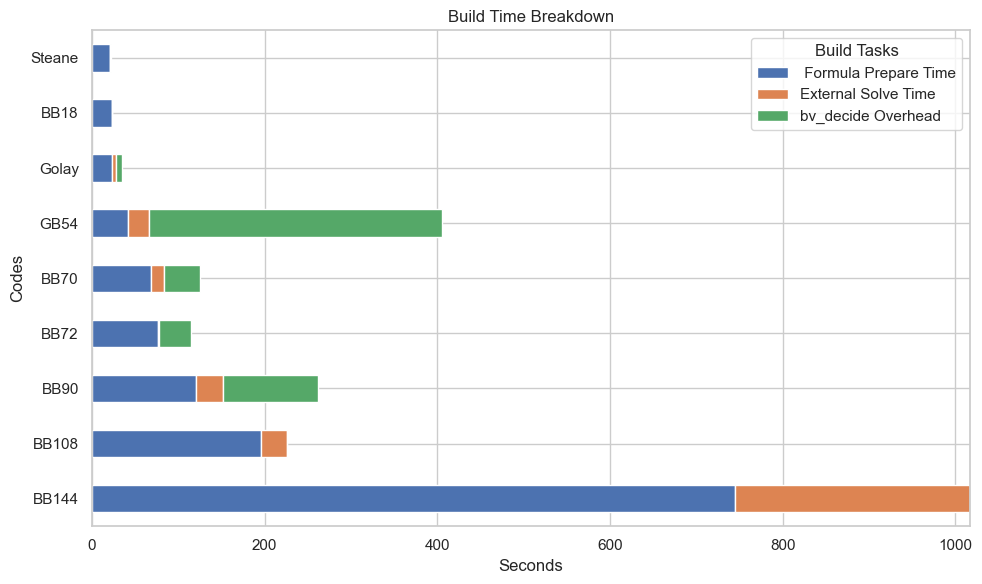

In [17]:
df.set_index(name_col, inplace=True)

columns_to_plot = [prep_col, calculated_col, diff_col]

df[columns_to_plot].plot(kind='barh', stacked=True, figsize=(10, 6))

plt.title('Build Time Breakdown')
plt.xlabel('Seconds')
plt.ylabel('Codes')
plt.legend(title='Build Tasks')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:

df_long = pd.melt(
    df, 
    id_vars=[name_col], 
    value_vars=[value_col, calculated_col],
    var_name="Type", 
    value_name="Value"
)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
custom_colors = {value_col: "#2ecc71", calculated_col: "#f1c40f"}
ax = sns.barplot(
    x="Value", 
    y=name_col, 
    hue="Type", 
    data=df_long, 
    palette=custom_colors
)
plt.title(f"Comparison of Lean build time and external CaDiCal solve time by code", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=12, labelpad=10)
plt.ylabel("Code", fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("build_times.png", dpi=300)
print(f"Graph successfully generated and saved to: {"build_times.png"}")


In [ ]:
def trim_csv_commas(filename):
    # 1. Read everything into memory
    with open(filename, 'r', encoding='utf-8') as file:
        lines = [line.strip().rstrip(',') for line in file]
        
    # 2. Overwrite the original file with the cleaned lines
    with open(filename, 'w', encoding='utf-8', newline='') as file:
        for line in lines:
            file.write(line + '\n')

In [ ]:
df = pd.read_csv("bvd_times.csv")
# Extract the first column's data
df_diff = df.diff(axis=1).fillna(df).astype(int)


print(df_diff)

       start   normalize   aig   cnf   solve    end
0  244440381        1017     2    12       2    158
1  339970513       29911     3    73      11  36572
2  340630001       19262     3    37       5   1518


In [2]:
df1 = pd.read_csv("cadical_results.csv")
df2 = pd.read_csv("kissat_results.csv")
print("cadical_head")
print(df1.head())

cadical_head
                                                  s    e  e.1    d
t   i                   m          e   _   s      o    l    v    e
s   i                   z          e   _   b      y    t    e    s
166  215.6386170387268   313772339 nan nan nan  NaN  NaN  NaN  NaN
362  196.09940147399902  290712044 nan nan nan  NaN  NaN  NaN  NaN
172  179.85713076591492  251965766 nan nan nan  NaN  NaN  NaN  NaN
